Yuheng Zhou 5753411
WM9QG: Fundamentals of Artificial Intelligence and Data Mining
February 2026

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

# Create directories if they don't exist
os.makedirs('./data', exist_ok=True)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Setup complete.")

Setup complete.


## 1. Data Loading

In [2]:
# Load all CSV files
print("Loading data files...")

raw = pd.read_csv('./data/CDC Diabetes Dataset.csv')
print(f"Raw CDC Diabetes Dataset: {raw.shape}")

print("\nData loading complete.")

Loading data files...
Raw CDC Diabetes Dataset: (253680, 22)

Data loading complete.


## 2. Data Understanding (EDA + Quality Checks)

In [3]:
# Check raw data structure
print("=== Raw CDC Diabetes Dataset ===")
print(f"Shape: {raw.shape}")
print(f"\nColumns: {list(raw.columns)}")
print(f"\nMissing values:\n{raw.isnull().sum()}")

=== Raw CDC Diabetes Dataset ===
Shape: (253680, 22)

Columns: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Missing values:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [4]:
# Check top rows of raw data
print("\n=== First 10 rows ===")
display(raw.head(10))


=== First 10 rows ===


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [5]:
# Check for duplicates
print("\n=== Duplicates ===")
dup_count = int(raw.duplicated().sum())
print(f"Duplicate rows: {dup_count}")


=== Duplicates ===
Duplicate rows: 23899


In [6]:

# Target distribution & imbalance
print("\n=== Target Variable Distribution ===")
target = "Diabetes_012"
if target in raw.columns:
    target_counts = raw[target].value_counts(dropna=False).sort_index()
    target_pct = (target_counts / len(raw) * 100).round(2)
    print("Counts:")
    print(target_counts)
    print("\nPercent (%):")
    print(target_pct)
else:
    print(f"Target column '{target}' not found in raw dataset.")


=== Target Variable Distribution ===
Counts:
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

Percent (%):
Diabetes_012
0.0    84.24
1.0     1.83
2.0    13.93
Name: count, dtype: float64


In [7]:
# Check encoding validity (Binary / Ordinal Ranges)
print("\n=== Encoding Validity (Binary / Ordinal Ranges) ===")

    # Binary columns expected in {0,1}
binary_cols = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke',
    'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
    'HvyAlcoholConsump','AnyHealthCare','NoDocbcCost',
    'DiffWalk','Sex'
]
binary_cols = [c for c in binary_cols if c in raw.columns]
binary_invalid = {}
for col in binary_cols:
    vals = pd.Series(raw[col].dropna().unique()).sort_values().tolist()
    invalid_vals = [v for v in vals if v not in [0, 1]]
    if invalid_vals:
        binary_invalid[col] = {"unique": vals, "invalid": invalid_vals}

if binary_cols:
    print(f"Binary columns checked: {binary_cols}")
    if binary_invalid:
        print("Binary encoding issues found:")
        for k, v in binary_invalid.items():
            print(f"- {k}: invalid values {v['invalid']} (unique={v['unique']})")
    else:
        print("All checked binary columns conform to {0,1}.")
else:
    print("No binary columns found from the expected list (check your column names).")

# Ordinal ranges (inclusive)
ordinal_ranges = {
    'GenHlth': (1, 5),
    'MentHlth': (0, 30),
    'PhysHlth': (0, 30),
    'Age': (1, 13),
    'Education': (1, 6),
    'Income': (1, 8)
}
ordinal_ranges = {k: v for k, v in ordinal_ranges.items() if k in raw.columns}

ordinal_invalid = {}
for col, (lo, hi) in ordinal_ranges.items():
    bad = raw[(raw[col] < lo) | (raw[col] > hi)][col]
    if len(bad) > 0:
        ordinal_invalid[col] = {
            "range": (lo, hi),
            "n_invalid": int(len(bad)),
            "example_values": sorted(bad.unique().tolist())[:10]
        }

if ordinal_ranges:
    print(f"Ordinal columns checked: {list(ordinal_ranges.keys())}")
    if ordinal_invalid:
        print("Ordinal range issues found:")
        for k, v in ordinal_invalid.items():
            print(f"- {k}: expected {v['range']}, invalid n={v['n_invalid']}, examples={v['example_values']}")
    else:
        print("All checked ordinal columns fall within expected ranges.")
else:
    print("No ordinal columns found from the expected list (check your column names).")



=== Encoding Validity (Binary / Ordinal Ranges) ===
Binary columns checked: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'NoDocbcCost', 'DiffWalk', 'Sex']
All checked binary columns conform to {0,1}.
Ordinal columns checked: ['GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
All checked ordinal columns fall within expected ranges.


In [8]:
# Check numeric plausibility  (BMI, PhysHlth, MentHlth)
print("\n=== Numeric Plausibility ===")

numeric_checks = {}

if "BMI" in raw.columns:
    bmi_desc = raw["BMI"].describe()
    numeric_checks["BMI_desc"] = bmi_desc
    # soft plausibility bounds (not medical)
    extreme_bmi = raw[(raw["BMI"] < 10) | (raw["BMI"] > 70)]["BMI"]
    numeric_checks["BMI_extreme_count"] = int(extreme_bmi.shape[0])
    print("BMI describe:")
    print(bmi_desc)
    print(f"Extreme BMI count (<10 or >70): {int(extreme_bmi.shape[0])}")

for col in ["PhysHlth", "MentHlth"]:
    if col in raw.columns:
        desc = raw[col].describe()
        numeric_checks[f"{col}_desc"] = desc
        out_of_range = raw[(raw[col] < 0) | (raw[col] > 30)][col]
        numeric_checks[f"{col}_out_of_range_count"] = int(out_of_range.shape[0])
        print(f"\n{col} describe:")
        print(desc)
        print(f"*** {col} out-of-range count (<0 or >30): {int(out_of_range.shape[0])} ***")



=== Numeric Plausibility ===
BMI describe:
count    253680.000000
mean         28.382364
std           6.608694
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          98.000000
Name: BMI, dtype: float64
Extreme BMI count (<10 or >70): 584

PhysHlth describe:
count    253680.000000
mean          4.242081
std           8.717951
min           0.000000
25%           0.000000
50%           0.000000
75%           3.000000
max          30.000000
Name: PhysHlth, dtype: float64
*** PhysHlth out-of-range count (<0 or >30): 0 ***

MentHlth describe:
count    253680.000000
mean          3.184772
std           7.412847
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          30.000000
Name: MentHlth, dtype: float64
*** MentHlth out-of-range count (<0 or >30): 0 ***


In [9]:
# Check for constant / near-constant features
print("\n=== Constant / Near-Constant Features ===")
nunique = raw.nunique(dropna=False).sort_values()
constant_cols = nunique[nunique <= 1]
print("Constant columns:" if len(constant_cols) else "No constant columns detected.")
if len(constant_cols):
    print(constant_cols)

max_freq = raw.apply(lambda col: col.value_counts(normalize=True).max())
near_constant_features = max_freq[max_freq >= 0.95]
print("Near-constant features (frequency >= 95%):" if len(near_constant_features) else "No near-constant features detected.")
if len(near_constant_features):
    print(near_constant_features)


=== Constant / Near-Constant Features ===
No constant columns detected.
Near-constant features (frequency >= 95%):
CholCheck        0.962670
Stroke           0.959429
AnyHealthcare    0.951053
dtype: float64


In [10]:
# Group means by Diabetes_012
print("\n=== Group Means by Diabetes_012 ===")
if target in raw.columns:
    # only numeric cols
    numeric_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
    if target in numeric_cols:
        numeric_cols.remove(target)
    group_means = raw.groupby(target)[numeric_cols].mean().round(3)
    display(group_means)
else:
    print(f"Skipping group means because target '{target}' not found.")


=== Group Means by Diabetes_012 ===


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_012,,,,,,,,,,,,,,,,,,,,,
0.0,0.371,0.379,0.957,27.743,0.430,0.032,0.072,0.779,0.643,0.821,0.062,0.950,0.080,2.372,2.944,3.582,0.132,0.434,7.787,5.107,6.209
1.0,0.629,0.621,0.987,30.724,0.493,0.057,0.143,0.678,0.602,0.769,0.045,0.945,0.129,2.976,4.530,6.348,0.277,0.438,9.083,4.784,5.351
2.0,0.753,0.670,0.993,31.944,0.518,0.092,0.223,0.631,0.585,0.756,0.024,0.960,0.106,3.291,4.462,7.954,0.371,0.479,9.379,4.746,5.210



=== Numeric features statistics ===


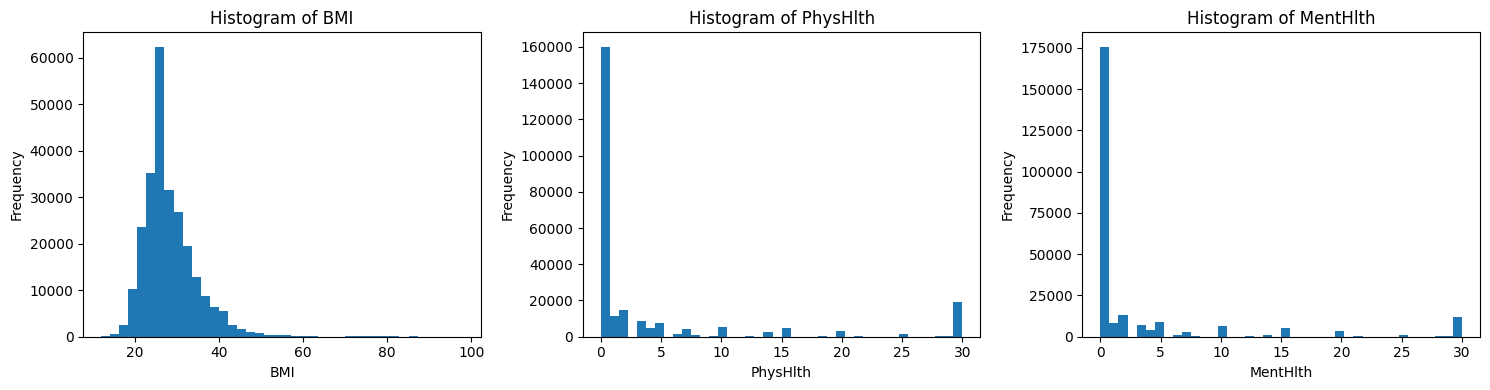

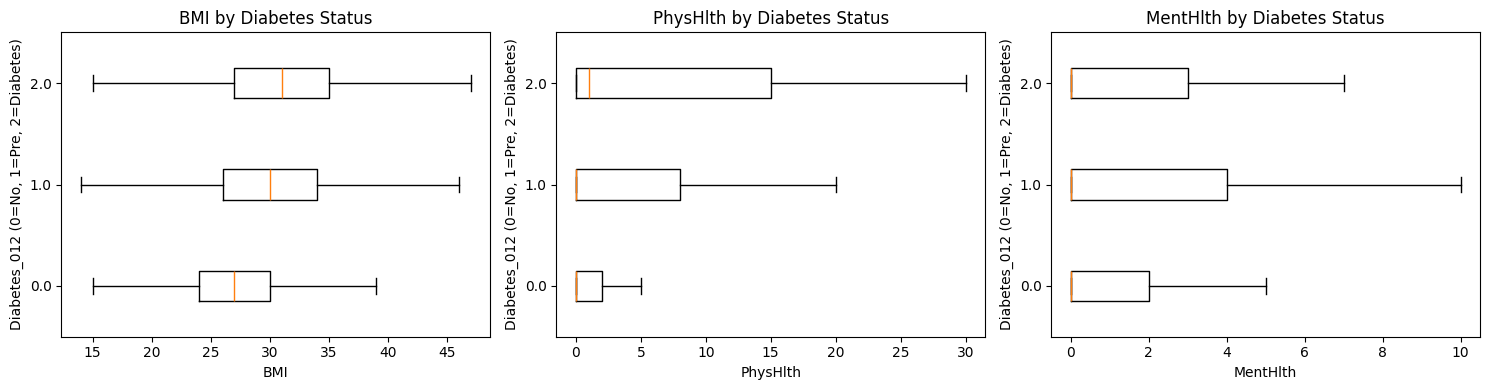

In [11]:
# Some charts of numeric features
print("\n=== Numeric features statistics ===")

numeric_features = ['BMI', 'PhysHlth', 'MentHlth']
## Histograms
plt.figure(figsize=(15, 4))

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)
    plt.hist(raw[feature], bins=40)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Boxplots by Diabetes_012
plt.figure(figsize=(15, 4))

groups = sorted(raw['Diabetes_012'].unique())

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)

    data = [
        raw.loc[raw['Diabetes_012'] == g, feature]
        for g in groups
    ]

    plt.boxplot(
        data,
        vert=False,
        tick_labels=groups,
        showfliers=False
    )

    plt.title(f'{feature} by Diabetes Status')
    plt.xlabel(feature)
    plt.ylabel('Diabetes_012 (0=No, 1=Pre, 2=Diabetes)')

plt.tight_layout()
plt.show()



=== Proportions of binary (lifestyle) features by Diabetes_012 ===


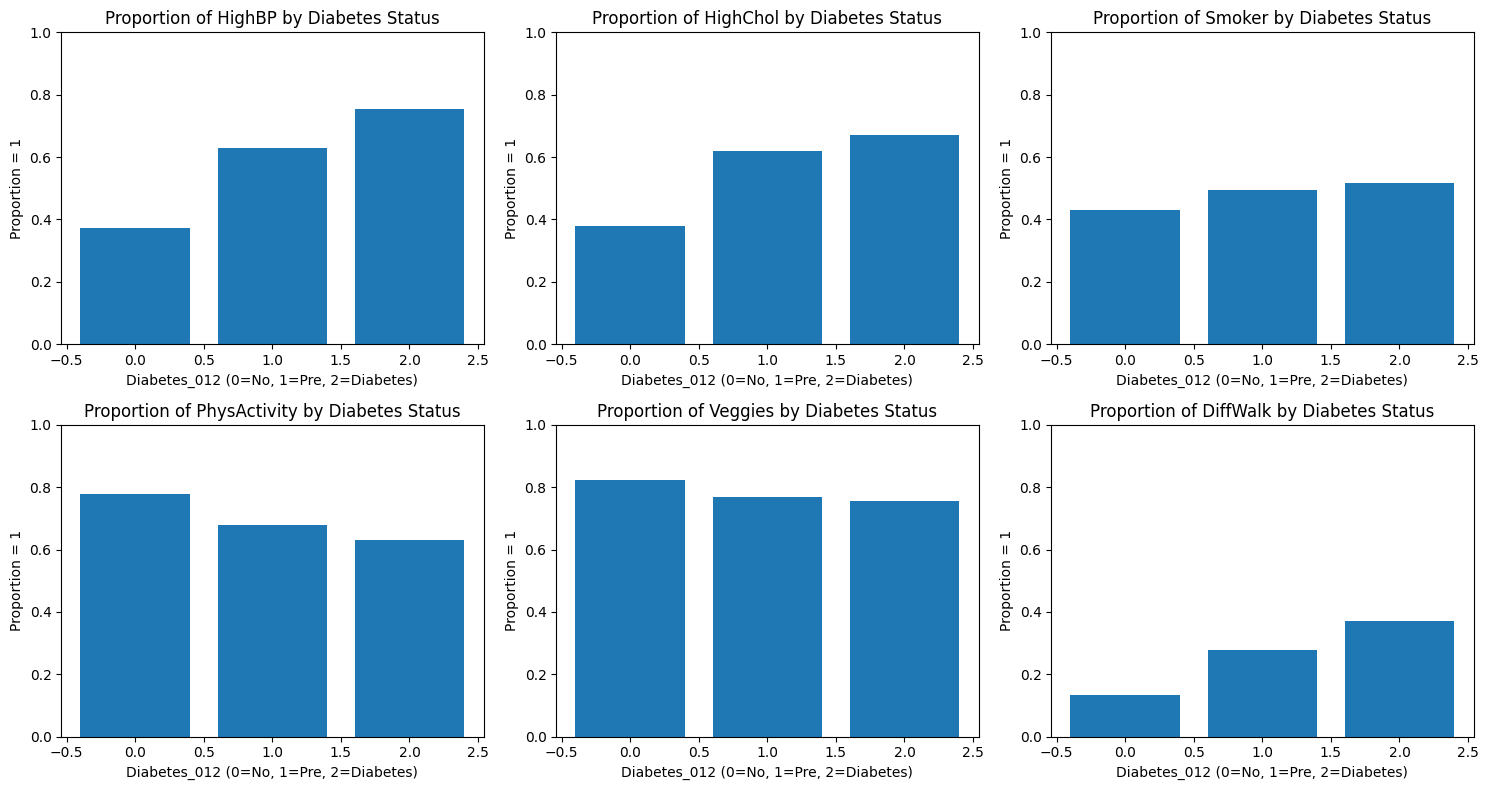

In [12]:
# Proportions of binary features by Diabetes_012
print("\n=== Proportions of binary (lifestyle) features by Diabetes_012 ===")

features_to_plot = [
    'HighBP',
    'HighChol',
    'Smoker',
    'PhysActivity',
    'Veggies',
    'DiffWalk'
]

groups = sorted(raw['Diabetes_012'].unique())

plt.figure(figsize=(15, 8))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)

    proportions = [
        raw.loc[raw['Diabetes_012'] == g, feature].mean()
        for g in groups
    ]

    plt.bar(groups, proportions)
    plt.ylim(0, 1)
    plt.title(f'Proportion of {feature} by Diabetes Status')
    plt.xlabel('Diabetes_012 (0=No, 1=Pre, 2=Diabetes)')
    plt.ylabel('Proportion = 1')

plt.tight_layout()
plt.show()
